In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree

## Get the Data 

In [2]:
#https://www.kaggle.com/uciml/iris

url_='https://drive.google.com/uc?id=10vsX925g8ff4QdgQpnsguo4DHUHOPgAL'
df = pd.read_csv(url_)

In [3]:
df.shape

(150, 6)

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [6]:
X = df.drop(['Id', 'Species'], axis = 1)
y = df['Species']

In [7]:
type(X) # DataFrame

pandas.DataFrame

In [8]:
type(y) # Series

pandas.Series

In [9]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: str

In [11]:
set(y) ## labels

{'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

In [12]:
X.shape

(150, 4)

In [13]:
y.shape

(150,)

## Split data to Train and Test Sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20) # 20%

In [15]:
(X_train.shape, y_train.shape)

((120, 4), (120,))

In [16]:
(X_test.shape, y_test.shape)

((30, 4), (30,))

### Decision Tree - create instance

In [17]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
model = DecisionTreeClassifier(criterion='gini')

### Decision Tree - train model

In [18]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Decision Tree - make a prediction

In [19]:
y_pred = model.predict(X_test)
y_pred_s = pd.Series(y_pred)

In [20]:
type(y_pred)

numpy.ndarray

In [21]:
y_pred_s

0         Iris-setosa
1         Iris-setosa
2     Iris-versicolor
3     Iris-versicolor
4     Iris-versicolor
5         Iris-setosa
6     Iris-versicolor
7     Iris-versicolor
8         Iris-setosa
9     Iris-versicolor
10     Iris-virginica
11        Iris-setosa
12    Iris-versicolor
13        Iris-setosa
14     Iris-virginica
15        Iris-setosa
16     Iris-virginica
17    Iris-versicolor
18     Iris-virginica
19     Iris-virginica
20    Iris-versicolor
21        Iris-setosa
22     Iris-virginica
23    Iris-versicolor
24     Iris-virginica
25        Iris-setosa
26    Iris-versicolor
27        Iris-setosa
28    Iris-versicolor
29    Iris-versicolor
dtype: str

In [22]:
type(y_test)

pandas.Series

In [23]:
# combine to view
s3 = pd.Series(list(zip(y_pred_s, y_test)))
s3

0             (Iris-setosa, Iris-setosa)
1             (Iris-setosa, Iris-setosa)
2     (Iris-versicolor, Iris-versicolor)
3      (Iris-versicolor, Iris-virginica)
4     (Iris-versicolor, Iris-versicolor)
5             (Iris-setosa, Iris-setosa)
6     (Iris-versicolor, Iris-versicolor)
7     (Iris-versicolor, Iris-versicolor)
8             (Iris-setosa, Iris-setosa)
9     (Iris-versicolor, Iris-versicolor)
10      (Iris-virginica, Iris-virginica)
11            (Iris-setosa, Iris-setosa)
12    (Iris-versicolor, Iris-versicolor)
13            (Iris-setosa, Iris-setosa)
14      (Iris-virginica, Iris-virginica)
15            (Iris-setosa, Iris-setosa)
16      (Iris-virginica, Iris-virginica)
17    (Iris-versicolor, Iris-versicolor)
18     (Iris-virginica, Iris-versicolor)
19      (Iris-virginica, Iris-virginica)
20    (Iris-versicolor, Iris-versicolor)
21            (Iris-setosa, Iris-setosa)
22      (Iris-virginica, Iris-virginica)
23    (Iris-versicolor, Iris-versicolor)
24      (Iris-vi

## Model Evaluation

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.85      0.92      0.88        12
 Iris-virginica       0.86      0.75      0.80         8

       accuracy                           0.90        30
      macro avg       0.90      0.89      0.89        30
   weighted avg       0.90      0.90      0.90        30



In [26]:
print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0 11  1]
 [ 0  2  6]]


## Visualization

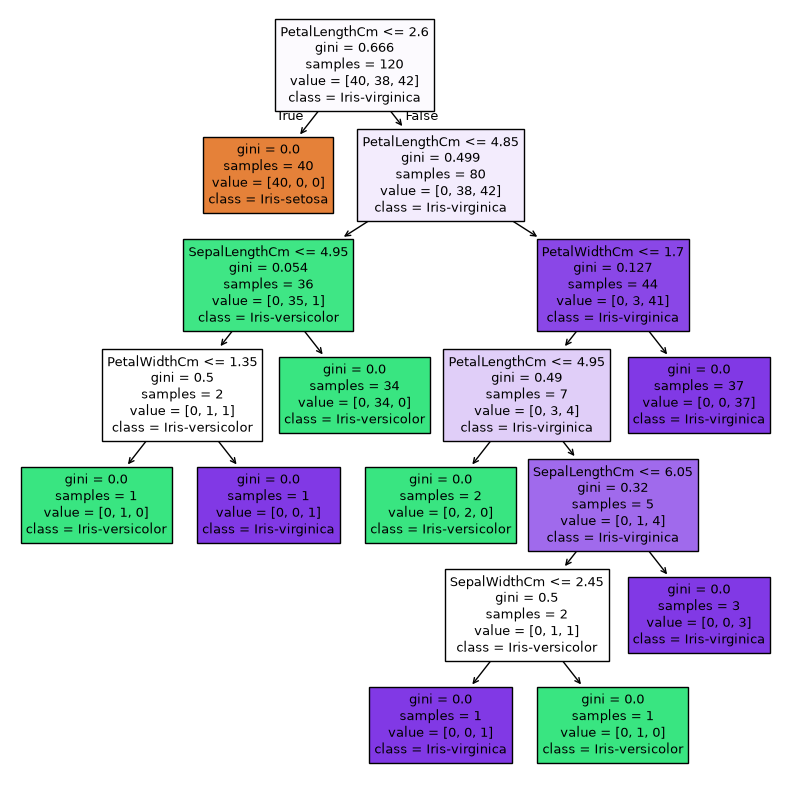

In [27]:
plt.figure(figsize = (10, 10))
plot_tree(model, feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], 
          class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], filled = True)
plt.show()